<a href="https://colab.research.google.com/github/deblinamandal2002/Supply-Chain-Analysis/blob/main/Supply_Chain_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Business Problem**

The global e-commerce company is experiencing frequent delivery delays and inaccurate promised shipping timelines, leading to reduced customer trust, higher operational costs, and lower order profitability.

### **Desired Outcome**

Improve on-time delivery performance, identify causes of delays, predict high-risk shipments in advance, and optimize logistics operations to increase customer satisfaction and profitability.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from warnings import filterwarnings
filterwarnings('ignore')

In [7]:
#Set professional color theme
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

viridis_color = cm.viridis(np.linspace(0, 1, 5))
primary_color = viridis_color[0]
secondary_color = viridis_color[1]
accent_color = viridis_color[2]
danger_color = '#800000'
neutral_color = viridis_color[4]
custom_palatte = viridis_color

In [8]:
import pandas as pd
df = pd.read_csv('/content/sample_data/DataCoSupplyChainDataset.csv', encoding='latin-1')

In [11]:
df

,Type,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer Country,Customer Segment,Department Name,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Order Region,Order Status,Product Name,Product Price,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,314.640015,Advance shipping,0,Sporting Goods,Puerto Rico,Consumer,Fitness,1/31/2018 22:56,0.29,327.750000,91.250000,Southeast Asia,COMPLETE,Smart watch,327.750000,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,311.359985,Late delivery,1,Sporting Goods,Puerto Rico,Consumer,Fitness,1/13/2018 12:27,-0.80,327.750000,-249.089996,South Asia,PENDING,Smart watch,327.750000,1/18/2018 12:27,Standard Class
2,CASH,4,4,309.720001,Shipping on time,0,Sporting Goods,EE. UU.,Consumer,Fitness,1/13/2018 12:06,-0.80,327.750000,-247.779999,South Asia,CLOSED,Smart watch,327.750000,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,304.809998,Advance shipping,0,Sporting Goods,EE. UU.,Home Office,Fitness,1/13/2018 11:45,0.08,327.750000,22.860001,Oceania,COMPLETE,Smart watch,327.750000,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,298.250000,Advance shipping,0,Sporting Goods,Puerto Rico,Corporate,Fitness,1/13/2018 11:24,0.45,327.750000,134.210007,Oceania,PENDING_PAYMENT,Smart watch,327.750000,1/15/2018 11:24,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,399.980011,Shipping on time,0,Fishing,EE. UU.,Home Office,Fan Shop,1/16/2016 3:40,0.10,399.980011,40.000000,Eastern Asia,CLOSED,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,1/20/2016 3:40,Standard Class
180515,DEBIT,3,2,395.980011,Late delivery,1,Fishing,EE. UU.,Corporate,Fan Shop,1/16/2016 1:34,-1.55,399.980011,-613.770019,Eastern Asia,COMPLETE,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,1/19/2016 1:34,Second Class
180516,TRANSFER,5,4,391.980011,Late delivery,1,Fishing,EE. UU.,Corporate,Fan Shop,1/15/2016 21:00,0.36,399.980011,141.110001,Oceania,PENDING,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,1/20/2016 21:00,Standard Class
180517,PAYMENT,3,4,387.980011,Advance shipping,0,Fishing,Puerto Rico,Consumer,Fan Shop,1/15/2016 20:18,0.48,399.980011,186.229996,Oceania,PENDING_PAYMENT,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,1/18/2016 20:18,Standard Class


In [23]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Sales per customer', 'Delivery Status', 'Late_delivery_risk',
       'Category Name', 'Customer Country', 'Customer Segment',
       'Department Name', 'order date (DateOrders)', 'Order Item Profit Ratio',
       'Sales', 'Order Profit Per Order', 'Order Region', 'Order Status',
       'Product Name', 'Product Price', 'shipping date (DateOrders)',
       'Shipping Mode'],
      dtype='object')

# **Exploratory Data Analysis(EDA)**

In [17]:
#Overview
print('rows, cols:',df.shape)
print('\ncolumns: ')
print(df.columns.tolist())
print('\nNum duplicates:',df.duplicated().sum())
print('\nMissing Values (top 20):')
print(df.isna().sum().sort_values(ascending=False).head(20))

rows, cols: (172765, 20)

columns: 
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Name', 'Customer Country', 'Customer Segment', 'Department Name', 'order date (DateOrders)', 'Order Item Profit Ratio', 'Sales', 'Order Profit Per Order', 'Order Region', 'Order Status', 'Product Name', 'Product Price', 'shipping date (DateOrders)', 'Shipping Mode']

Num duplicates: 0

Missing Values (top 20):
Type                             0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Sales per customer               0
Delivery Status                  0
Late_delivery_risk               0
Category Name                    0
Customer Country                 0
Customer Segment                 0
Department Name                  0
order date (DateOrders)          0
Order Item Profit Ratio          0
Sales                            0
Order Profit Per Order           0
Order Region       

In [24]:
(df['Order Status'] == df['Order Profit Per Order']).value_counts()

,count
False,172765


## Data Cleaning

In [26]:
columns_to_drop = [  'Product Description',
    'Product Image',
    'Customer Email',
    'Customer Password',
    'Customer Fname',
    'Customer Lname',
    'Customer Street',
    'Customer Zipcode',
    'Order Zipcode',
    'Longitude',
    'Latitude',
    'Order Item Cardprod Id',
    'Order Item Id',
    'Order Item Discount',
    'Order Item Discount Rate',
    'Order Item Product Price',
    'Order Item Quantity',
    'Order Item Total',
    'Category Id',
    'Department Id',
    'Order Id',
    'Order Customer Id',
    'Customer Id',
    'Product Card Id',
    'Product Category Id',
    'Benefit per order',   # duplicate of profit
    'Product Status',      # single value column
    'Customer City',
    'Order City',
    'Order Country',
    'Order State',
    'Customer State',
    'Market']
# dropping columns that are either fully missing , redundant, or have only one value(and thus no variance )
df = df.drop(columns=columns_to_drop, errors='ignore')

#removing canceled orders since they are not relevant for delivery time analysis and may have different patterns than completed orders
df = df[df['Delivery Status'] != 'Shipping canceled']

#Standard Data Conversion
for c in ['order date (DateOrders)', 'shipping date (DateOrders)']:
    df[c] = pd.to_datetime(df[c], errors = 'coerce', dayfirst=False)


#After data clean , lets chechk overview again to see how the dataset has changed
print('rows, cols:',df.shape)
print('\nMissing Values(top 5):')
print(df.isna().sum().sort_values(ascending=False).head(5))

rows, cols: (172765, 20)

Missing Values(top 5):
Type                             0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Sales per customer               0
Delivery Status                  0
dtype: int64


In [27]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer Country,Customer Segment,Department Name,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Order Region,Order Status,Product Name,Product Price,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,314.640015,Advance shipping,0,Sporting Goods,Puerto Rico,Consumer,Fitness,2018-01-31 22:56:00,0.29,327.75,91.250000,Southeast Asia,COMPLETE,Smart watch,327.75,2018-02-03 22:56:00,Standard Class
1,TRANSFER,5,4,311.359985,Late delivery,1,Sporting Goods,Puerto Rico,Consumer,Fitness,2018-01-13 12:27:00,-0.80,327.75,-249.089996,South Asia,PENDING,Smart watch,327.75,2018-01-18 12:27:00,Standard Class
2,CASH,4,4,309.720001,Shipping on time,0,Sporting Goods,EE. UU.,Consumer,Fitness,2018-01-13 12:06:00,-0.80,327.75,-247.779999,South Asia,CLOSED,Smart watch,327.75,2018-01-17 12:06:00,Standard Class
3,DEBIT,3,4,304.809998,Advance shipping,0,Sporting Goods,EE. UU.,Home Office,Fitness,2018-01-13 11:45:00,0.08,327.75,22.860001,Oceania,COMPLETE,Smart watch,327.75,2018-01-16 11:45:00,Standard Class
4,PAYMENT,2,4,298.250000,Advance shipping,0,Sporting Goods,Puerto Rico,Corporate,Fitness,2018-01-13 11:24:00,0.45,327.75,134.210007,Oceania,PENDING_PAYMENT,Smart watch,327.75,2018-01-15 11:24:00,Standard Class


In [28]:
#value counts for categorical columns with low cardinality
for col in df.columns:
  if df[col].nunique() < 10:
    print(f'\n{col} valuecounrnts:')
    print(df[col].value_counts())


Type valuecounrnts:
Type
DEBIT       69295
TRANSFER    42129
PAYMENT     41725
CASH        19616
Name: count, dtype: int64

Days for shipping (real) valuecounrnts:
Days for shipping (real)
2    54205
6    27489
3    27478
4    27297
5    27003
0     4839
1     4454
Name: count, dtype: int64

Days for shipment (scheduled) valuecounrnts:
Days for shipment (scheduled)
4    103153
2     33806
1     26513
0      9293
Name: count, dtype: int64

Delivery Status valuecounrnts:
Delivery Status
Late delivery       98977
Advance shipping    41592
Shipping on time    32196
Name: count, dtype: int64

Late_delivery_risk valuecounrnts:
Late_delivery_risk
1    98977
0    73788
Name: count, dtype: int64

Customer Country valuecounrnts:
Customer Country
EE. UU.        106425
Puerto Rico     66340
Name: count, dtype: int64

Customer Segment valuecounrnts:
Customer Segment
Consumer       89420
Corporate      52528
Home Office    30817
Name: count, dtype: int64

Order Status valuecounrnts:
Order Status
CO

In [5]:
from google.colab import files
import os

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')
  # Move the uploaded file to the expected path if it's not already there
  if not os.path.exists('/content/sample_data/DataCoSupplyChainDataset.csv'):
    # Assuming the user uploads the correct file name
    os.rename(fn, '/content/sample_data/DataCoSupplyChainDataset.csv')

KeyboardInterrupt: 

In [6]:
import pandas as pd

df = pd.read_csv('/content/sample_data/DataCoSupplyChainDataset.csv', encoding='latin-1')

columns_to_drop = [  'Product Description',
    'Product Image',
    'Customer Email',
    'Customer Password',
    'Customer Fname',
    'Customer Lname',
    'Customer Street',
    'Customer Zipcode',
    'Order Zipcode',
    'Longitude',
    'Latitude',
    'Order Item Cardprod Id',
    'Order Item Id',
    'Order Item Discount',
    'Order Item Discount Rate',
    'Order Item Product Price',
    'Order Item Quantity',
    'Order Item Total',
    'Category Id',
    'Department Id',
    'Order Id',
    'Order Customer Id',
    'Customer Id',
    'Product Card Id',
    'Product Category Id',
    'Benefit per order',   # duplicate of profit
    'Product Status',      # single value column
    'Customer City',
    'Order City',
    'Order Country',
    'Order State',
    'Customer State',
    'Market']
# dropping columns that are either fully missing , redundant, or have only one value(and thus no variance )
df = df.drop(columns=columns_to_drop, errors='ignore')

#removing canceled orders since they are not relevant for delivery time analysis and may have different patterns than completed orders
df = df[df['Delivery Status'] != 'Shipping canceled']

#Standard Data Conversion
for c in ['order date (DateOrders)', 'shipping date (DateOrders)']:
    df[c] = pd.to_datetime(df[c], errors = 'coerce', dayfirst=False)


#After data clean , lets chechk overview again to see how the dataset has changed
print('rows, cols:',df.shape)
print('\nMissing Values(top 5):')
print(df.isna().sum().sort_values(ascending=False).head(5))

rows, cols: (88813, 20)

Missing Values(top 5):
Customer Segment      1
Customer Country      1
Category Name         1
Late_delivery_risk    1
Product Name          1
dtype: int64


In [7]:
#calculating order processing time and delay
df['Order Processing Time'] = (df['shipping date (DateOrders)'] - df['order date (DateOrders)']).dt.days
df['Delay'] = df['Order Processing Time'] - df['Days for shipment (scheduled)']
df['Is_Delayed'] = df['Delay'] > 0
df['Order Month'] = df['order date (DateOrders)'].dt.month
df['Order Day'] = df['order date (DateOrders)'].dt.day_name()
df['Order Hour'] = df['order date (DateOrders)'].dt.hour
df.describe( )

,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Late_delivery_risk,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Product Price,shipping date (DateOrders),Order Processing Time,Delay,Order Month,Order Hour
count,88813.000000,88813.000000,88813.000000,88812.000000,88812,88812.000000,88812.000000,88812.000000,88812.000000,88812,88812.000000,88812.000000,88812.000000,88812.000000
mean,3.480504,2.876471,176.214941,0.582264,2016-06-21 00:16:44.394000896,0.122114,196.152439,21.301355,137.248814,2016-06-24 11:49:14.454803200,3.453677,0.577219,6.222267,11.500146
min,0.000000,0.000000,7.490000,0.000000,2015-01-01 00:00:00,-2.750000,9.990000,-4274.979980,9.990000,2015-01-03 00:00:00,0.000000,-2.000000,1.000000,0.000000
25%,2.000000,2.000000,104.959999,0.000000,2015-09-11 07:52:00,0.080000,119.980003,6.557500,50.000000,2015-09-14 19:59:45,2.000000,0.000000,3.000000,5.000000
50%,3.000000,4.000000,163.979996,1.000000,2016-06-23 19:23:00,0.270000,199.949997,30.760000,99.989998,2016-06-27 15:11:00,3.000000,1.000000,6.000000,11.000000
75%,5.000000,4.000000,235.160004,1.000000,2017-03-26 05:20:00,0.360000,250.000000,62.419998,199.990005,2017-03-29 12:46:45,5.000000,1.000000,9.000000,17.000000
max,6.000000,4.000000,1919.989990,1.000000,2018-01-31 23:38:00,0.500000,1999.989990,864.000000,1999.989990,2018-02-06 13:29:00,6.000000,4.000000,12.000000,23.000000
std,1.619629,1.376799,119.306868,0.493189,NaN,0.464967,131.734057,102.246779,133.022887,NaN,1.668082,1.501098,3.387115,6.930248


In [8]:
df['Is_Delayed'].value_counts( )

,count
Is_Delayed,
True,49328
False,39485


In [9]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Sales per customer', 'Delivery Status', 'Late_delivery_risk',
       'Category Name', 'Customer Country', 'Customer Segment',
       'Department Name', 'order date (DateOrders)', 'Order Item Profit Ratio',
       'Sales', 'Order Profit Per Order', 'Order Region', 'Order Status',
       'Product Name', 'Product Price', 'shipping date (DateOrders)',
       'Shipping Mode', 'Order Processing Time', 'Delay', 'Is_Delayed',
       'Order Month', 'Order Day', 'Order Hour'],
      dtype='object')

In [10]:
df['Order Profit Per Order']

,Order Profit Per Order
0,91.250000
1,-249.089996
2,-247.779999
3,22.860001
4,134.210007
...,...
91322,113.540001
91323,-2.490000
91324,19.930000
91325,18.020000


In [13]:
import numpy as np
#Profitability flag based on Order Profit per Order
df['Profitability_Flag'] = np.where(df['Order Profit Per Order'] > 0, 'Profit', np.where(df['Order Profit Per Order'] < 0, 'Loss', 'Break Even'))
df['Profitability_Flag'].value_counts()

,count
Profitability_Flag,
Profit,71711
Loss,16520
Break Even,582


In [14]:
df['Profitability_Flag'].value_counts(normalize=True)

,proportion
Profitability_Flag,
Profit,0.807438
Loss,0.186009
Break Even,0.006553


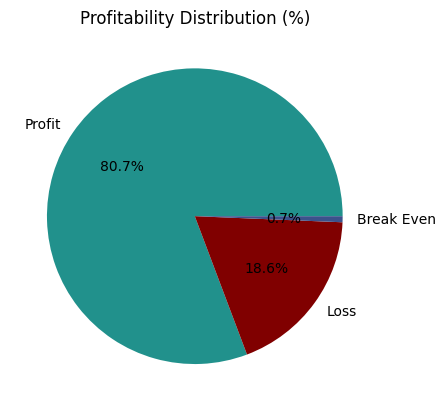

In [20]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

viridis_color = cm.viridis(np.linspace(0, 1, 5))
secondary_color = viridis_color[1]
accent_color = viridis_color[2]
danger_color = '#800000'

profit_counts = df['Profitability_Flag'].value_counts(normalize=True) * 100
profit_counts.plot(kind='pie', autopct='%1.1f%%', colors=[accent_color, danger_color, secondary_color])
plt.ylabel('')
plt.title('Profitability Distribution (%)')
plt.show()

In [21]:
def format_func(value):
    if value >= 1e6:
        return f'{value/1e6:.1f}M $'
    elif value >= 1e3:
        return f'{value/1e3:.1f}K $'
    else:
        return f'{value:.0f} $'

delayed_df = df[df['Delay'] > 0]
metrics = {}
metrics['Total Orders'] = len(df)
metrics['Late Deliveries'] = len(delayed_df)
metrics['90% Delay (days)'] = delayed_df['Delay'].quantile(0.90)
metrics['On time Delivery %'] = (1 - float(metrics['Late Deliveries']) / metrics['Total Orders']) * 100
metrics['Late Delivery %'] = float(metrics['Late Deliveries']) / metrics['Total Orders'] * 100
metrics['Total Profit'] = format_func(df.loc[df['Order Profit Per Order'] > 0, 'Order Profit Per Order'].sum())
metrics['Total Loss due to delays'] = format_func(df.loc[df['Delay'] > 0, 'Order Profit Per Order'].sum())

print('\n--- Business KPIs ---\n')
for k, v in metrics.items():
    if isinstance(v, float):
        print(f"{k}: {v:.2f}")
    else:
        print(f"{k}: {v}")


--- Business KPIs ---

Total Orders: 88813
Late Deliveries: 49328
90% Delay (days): 3.00
On time Delivery %: 44.46
Late Delivery %: 55.54
Total Profit: 3.7M $
Total Loss due to delays: 1.0M $


# **Profitability vs Delivery Time Analysis**

In [22]:
profit_metrics = (
    df.groupby('Delay')['Order Profit Per Order']
    .agg(
        mean_profit='mean',
        total_profit='sum',
        order_count='count'
    )
    .reset_index()
)

In [23]:
profit_metrics

,Delay,mean_profit,total_profit,order_count
0,-2.0,23.298961,241330.640068,10358
1,-1.0,20.400531,208819.840155,10236
2,0.0,21.690902,409741.139893,18890
3,1.0,21.328911,591024.110428,27710
4,2.0,21.235277,299459.879824,14102
5,3.0,16.287007,61271.719828,3762
6,4.0,21.355514,80168.599936,3754


In [24]:
delay_distribution = (
    df['Delay']
    .value_counts(normalize=True)
    .sort_index() * 100
).reset_index()

In [25]:
delay_distribution

,Delay,proportion
0,-2.0,11.662838
1,-1.0,11.525470
2,0.0,21.269648
3,1.0,31.200739
4,2.0,15.878485
5,3.0,4.235914
6,4.0,4.226906



Profit Metrics by Delay Day:


,Delay,mean_profit,total_profit,order_count
0,-2.0,23.3,241330.6,10358
1,-1.0,20.4,208819.8,10236
2,0.0,21.7,409741.1,18890
3,1.0,21.3,591024.1,27710
4,2.0,21.2,299459.9,14102
5,3.0,16.3,61271.7,3762
6,4.0,21.4,80168.6,3754



Delay Distribution (%):


,Delay_Days,Percentage
0,-2.0,11.662838
1,-1.0,11.525470
2,0.0,21.269648
3,1.0,31.200739
4,2.0,15.878485
5,3.0,4.235914
6,4.0,4.226906


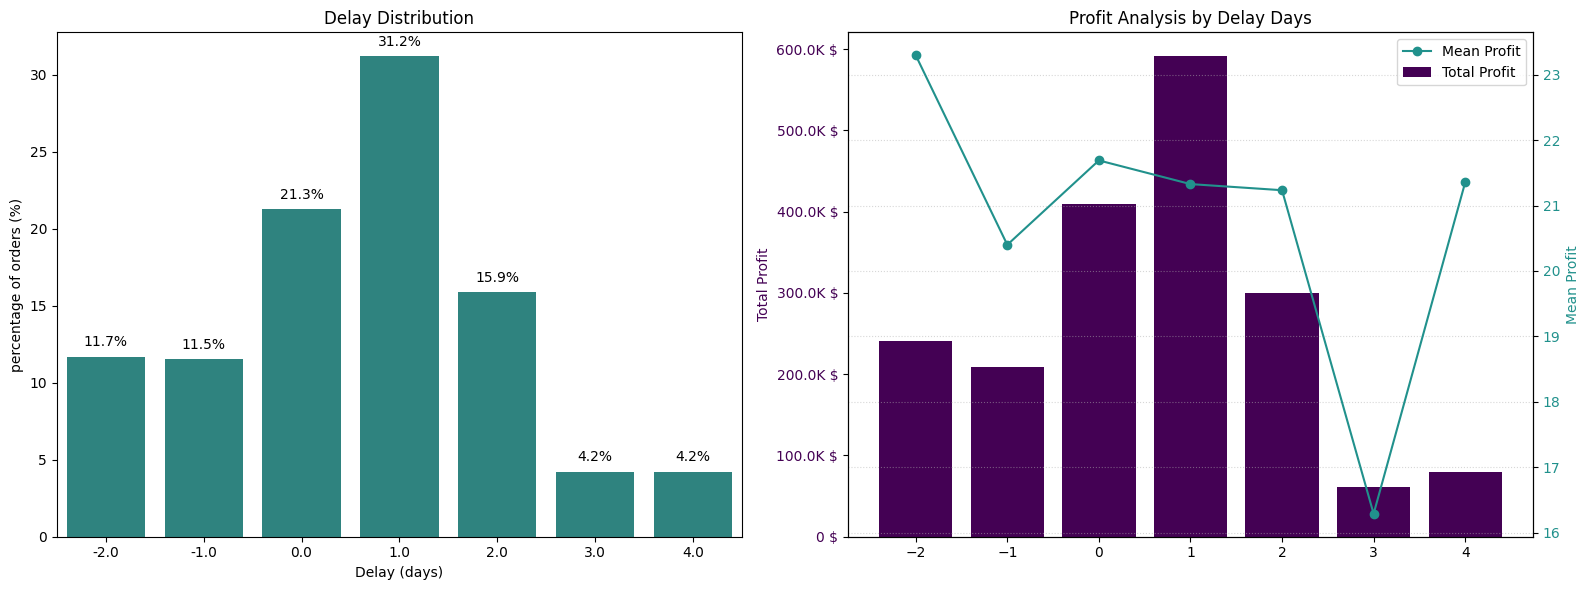

In [27]:
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import numpy as np

viridis_color = cm.viridis(np.linspace(0, 1, 5))
primary_color = viridis_color[0]
secondary_color = viridis_color[1]
accent_color = viridis_color[2]
danger_color = '#800000'

# Calculate distribution
delay_distribution = (
    df['Delay']
    .value_counts(normalize=True)
    .sort_index() * 100
).reset_index()

delay_distribution.columns = ['Delay_Days', 'Percentage']

print("\nProfit Metrics by Delay Day:")
display(profit_metrics.round(1))

print("\nDelay Distribution (%):")
display(delay_distribution)

# Create Subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- First subplot: Delay Distribution ---
sns.barplot(x='Delay_Days', y='Percentage', data=delay_distribution, color=accent_color, ax=ax1)
ax1.set_title('Delay Distribution')
ax1.set_xlabel('Delay (days)')
ax1.set_ylabel('percentage of orders (%)')

# Percentage text on bars
for bar in ax1.patches:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{height:.1f}%', ha='center', va='bottom')

# --- Second subplot: Profit Analysis by Delay Days ---
ax2.set_ylabel("Total Profit", color=primary_color)
ax2.bar(profit_metrics['Delay'], profit_metrics['total_profit'], color=primary_color, label='Total Profit')
ax2.tick_params(axis='y', labelcolor=primary_color)

ax3 = ax2.twinx()

ax3.set_xlabel("Delay Days")
ax3.set_ylabel("Mean Profit", color=accent_color)
ax3.plot(profit_metrics['Delay'], profit_metrics['mean_profit'], marker='o', label='Mean Profit', color=accent_color)
ax3.tick_params(axis='y', labelcolor=accent_color)

# Format total profit axis to K $, M $
def format_func(value, tick_number):
    if value >= 1e6:
        return f'{value/1e6:.1f}M $'
    elif value >= 1e3:
        return f'{value/1e3:.1f}K $'
    else:
        return f'{value:.0f} $'

ax2.yaxis.set_major_formatter(ticker.FuncFormatter(format_func))

ax3.set_title("Profit Analysis by Delay Days")

# Legends and grid
lines, labels = ax3.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax3.legend(lines + lines2, labels + labels2, loc='upper right')
ax3.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

# **Bottleneck Detection**

In [28]:
def compute_delay_pct_by_category(category):
    cat_df = df.groupby(category).agg(
        total_orders=('Delay', 'count'),
        late_orders=('Is_Delayed', 'sum')
    ).reset_index()

    cat_df['delay_pct'] = cat_df['late_orders'] / cat_df['total_orders'] * 100
    cat_df = cat_df.sort_values('delay_pct', ascending=False).head(10)
    return cat_df



In [30]:
compute_delay_pct_by_category('Customer Segment')

,Customer Segment,total_orders,late_orders,delay_pct
0,Consumer,41926,23664,56.442303
2,Home Office,8201,4526,55.188392
1,Corporate,38685,21138,54.641334


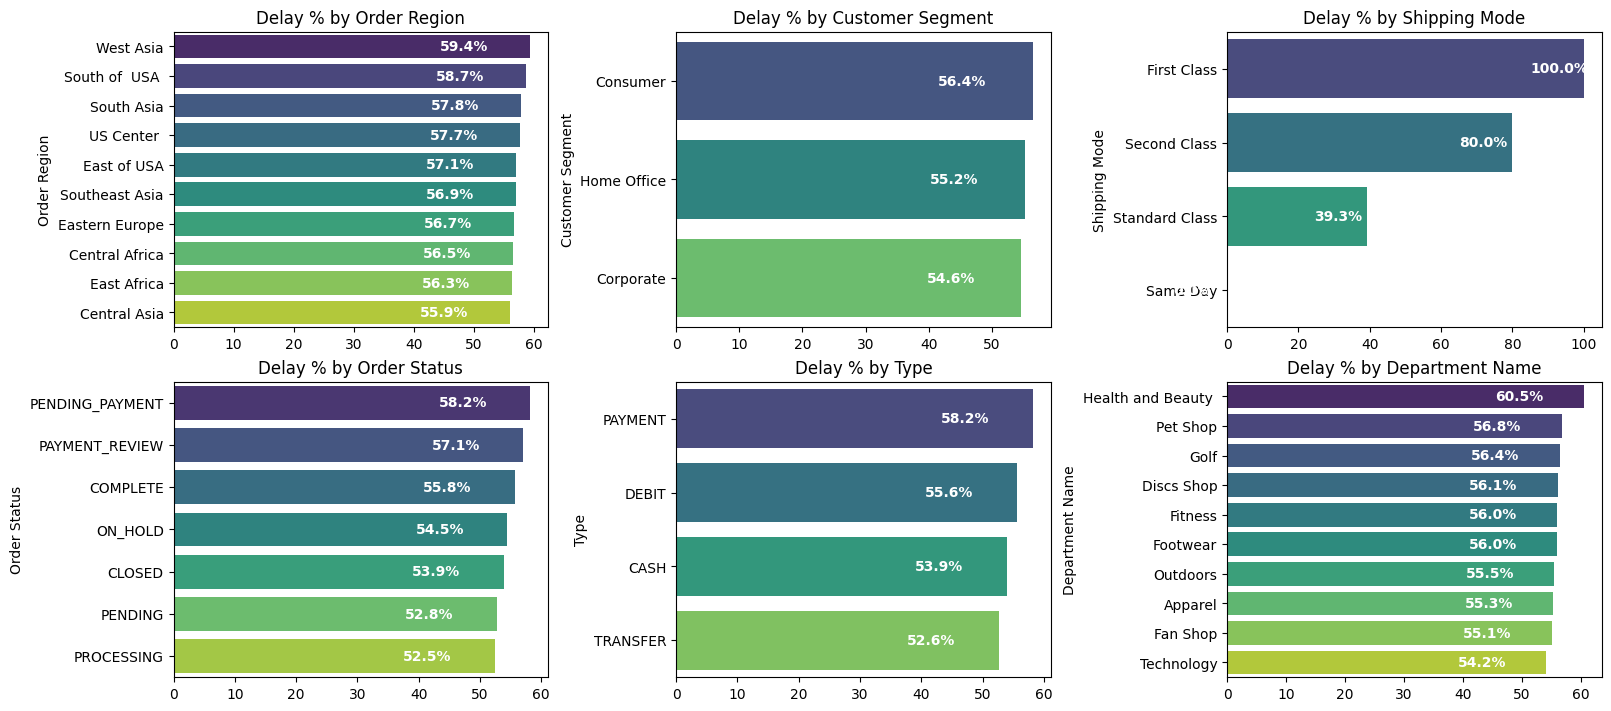

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define operational categories to analyze
categories = ['Order Region', 'Customer Segment', 'Shipping Mode', 'Order Status', 'Type', 'Department Name']

# Setup the grid
fig, axes = plt.subplots(2, 3, figsize=(16, 7), constrained_layout=True)
axes = axes.flatten()

# Loop through each category and plot
for ax, category in zip(axes, categories):
    cat_df = compute_delay_pct_by_category(category)

    sns.barplot(
        data=cat_df,
        x='delay_pct',
        y=category,
        ax=ax,
        palette='viridis'
    )

    ax.set_title(f'Delay % by {category}')
    ax.set_xlabel('')
    ax.set_ylabel(category)

    # Add text labels inside the bars
    for i, row in cat_df.reset_index().iterrows():
        ax.text(
            row['delay_pct'] - 15,
            i,
            f"{row['delay_pct']:.1f}%",
            va='center',
            fontsize=10,
            color='white',
            fontweight='bold'
        )

plt.show()

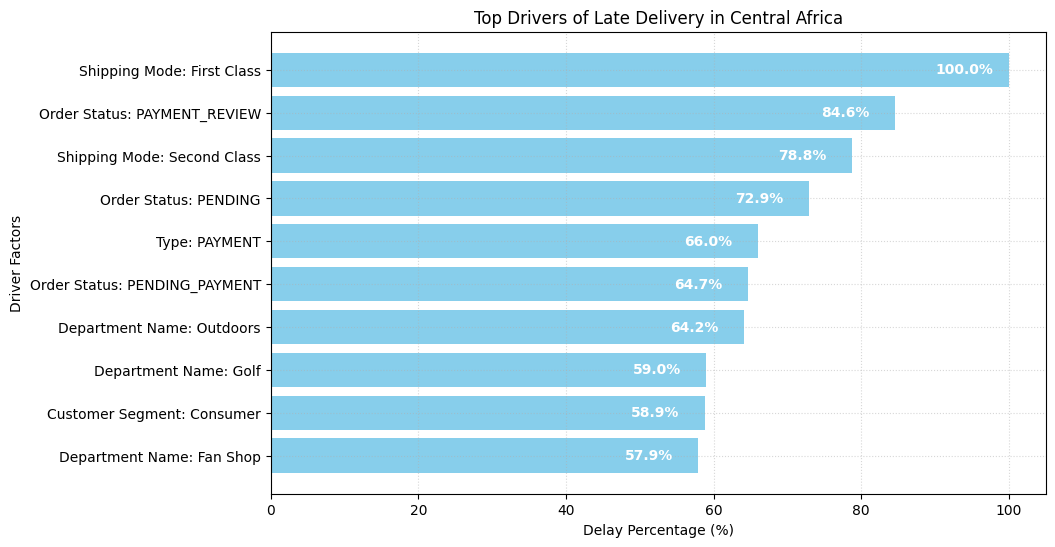

In [32]:
# Top drivers of late delivery by region
def top_drivers_for_region(region):
    df_region = df[df['Order Region'] == region].copy()

    drivers = ['Shipping Mode', 'Customer Segment', 'Department Name', 'Type', 'Order Status']

    all_factors = []
    for factor in drivers:
        temp = (
            df_region.groupby(factor)
            .agg(
                total_orders=('Delay', 'count'),
                late_orders=('Is_Delayed', 'sum'),
                avg_delay=('Delay', 'mean')
            )
            .reset_index()
        )

        temp['delay_pct'] = temp['late_orders'] / temp['total_orders'] * 100
        temp['Driver'] = factor
        temp['Factor_Level'] = factor + ": " + temp[factor].astype(str)

        all_factors.append(temp[['Driver', 'Factor_Level', 'delay_pct', 'avg_delay', 'total_orders']])

    # Combine all drivers
    final_df = pd.concat(all_factors)

    # Top 10 drivers
    top_factors = final_df.sort_values('delay_pct', ascending=False).head(10)
    plt.figure(figsize=(10, 6))

    bars = plt.barh(top_factors['Factor_Level'], top_factors['delay_pct'], color='skyblue')

    plt.xlabel("Delay Percentage (%)")
    plt.ylabel("Driver Factors")
    plt.title(f"Top Drivers of Late Delivery in {region}")
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.gca().invert_yaxis()

    for bar in bars:
        width = bar.get_width()
        plt.text(width - 10, bar.get_y() + bar.get_height()/2,
                 f"{width:.1f}%",
                 va='center', fontsize=10, color='white', fontweight='bold')

    plt.show()

# Example usage from the screenshot
top_drivers_for_region('Central Africa')

In [33]:
df['shipping date (DateOrders)'].max()

Timestamp('2018-02-06 13:29:00')

# **Time Based Data Analysis**

In [36]:
# Delay % by Month, Day of Week, Hour

delay_by_month = (
    df.groupby('Order Month')['Is_Delayed']
    .mean()
    .reset_index()
)
delay_by_month['delay_pct'] = delay_by_month['Is_Delayed'] * 100

delay_by_day = (
    df.groupby('Order Day')['Is_Delayed']
    .mean()
    .reset_index()
)
delay_by_day['delay_pct'] = delay_by_day['Is_Delayed'] * 100

delay_by_hour = (
    df.groupby('Order Hour')['Is_Delayed']
    .mean()
    .reset_index()
)
delay_by_hour['delay_pct'] = delay_by_hour['Is_Delayed'] * 100

In [37]:
delay_by_month

,Order Month,Is_Delayed,delay_pct
0,1.0,0.550143,55.014264
1,2.0,0.554659,55.465937
2,3.0,0.552211,55.221146
3,4.0,0.558729,55.872888
4,5.0,0.559866,55.986572
5,6.0,0.544896,54.489578
6,7.0,0.543588,54.358841
7,8.0,0.567993,56.799316
8,9.0,0.554832,55.483225
9,10.0,0.545769,54.576911


I discovered that December has the highest delay rate, likely due to holiday surge, and orders placed at 8 PM have a 57% delay risk, suggesting a staffing bottleneck during the late-night shift transition.

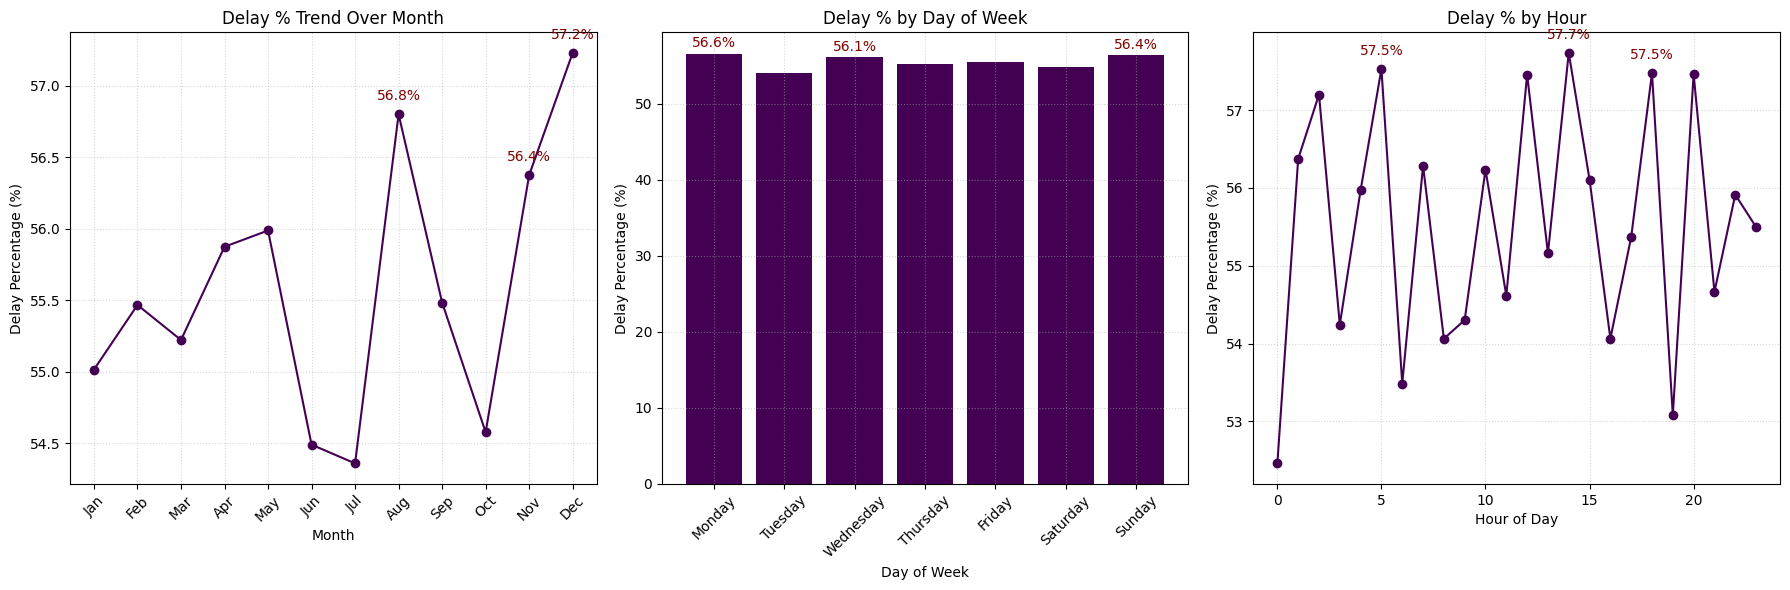

In [39]:
import matplotlib.pyplot as plt
import pandas as pd

# --- Step 1: Initialize the figure ---
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# --- Subplot 1: Delay % Trend Over Month ---
ax1.plot(delay_by_month['Order Month'], delay_by_month['delay_pct'], marker='o', color=primary_color)
ax1.set_xticks(range(1,13))
ax1.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)
ax1.set_xlabel("Month")
ax1.set_ylabel("Delay Percentage (%)")
ax1.set_title("Delay % Trend Over Month")
ax1.grid(True, linestyle=':', alpha=0.5)

# Annotate top 3 highest months
top3_month = delay_by_month.nlargest(3, 'delay_pct')
for _, row in top3_month.iterrows():
    ax1.annotate(f"{row['delay_pct']:.1f}%", (row['Order Month'], row['delay_pct']),
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=10, color=danger_color)

# --- Subplot 2: Delay % by Day of Week ---
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
delay_by_day['Order Day'] = pd.Categorical(delay_by_day['Order Day'], categories=day_order, ordered=True)
delay_by_day = delay_by_day.sort_values('Order Day')

ax2.bar(delay_by_day['Order Day'], delay_by_day['delay_pct'], color=primary_color)
ax2.set_xticklabels(delay_by_day['Order Day'], rotation=45)
ax2.set_xlabel("Day of Week")
ax2.set_ylabel("Delay Percentage (%)")
ax2.set_title("Delay % by Day of Week")
ax2.grid(True, linestyle=':', alpha=0.5)

# Annotate top 3 highest bars
top3_day = delay_by_day.nlargest(3, 'delay_pct')
for _, row in top3_day.iterrows():
    height = row['delay_pct']
    ax2.text(row['Order Day'], height + 0.5, f'{height:.1f}%', ha='center', va='bottom', fontsize=10, color=danger_color)

# --- Subplot 3: Delay % by Hour ---
ax3.plot(delay_by_hour['Order Hour'], delay_by_hour['delay_pct'], marker='o', color=primary_color)
ax3.set_xlabel("Hour of Day")
ax3.set_ylabel("Delay Percentage (%)")
ax3.set_title("Delay % by Hour")
ax3.grid(True, linestyle=':', alpha=0.5)

# Annotate top 3 highest hours
top3_hour = delay_by_hour.nlargest(3, 'delay_pct')
for _, row in top3_hour.iterrows():
    ax3.annotate(f"{row['delay_pct']:.1f}%", (row['Order Hour'], row['delay_pct']),
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=10, color=danger_color)

plt.tight_layout()
plt.show()

# **Machine Learning Modelling**

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from collections import Counter
from imblearn.over_sampling import SMOTE

In [42]:
X = df[['Type', 'Days for shipment (scheduled)', 'Category Name', 'Customer Segment', 'Department Name', 'Order Region', 'Shipping Mode', 'Order Month', 'Order Hour']]
y = df['Late_delivery_risk']

In [51]:
# 1. Select Features and Target
X = df[['Type', 'Days for shipment (scheduled)', 'Category Name', 'Customer Segment',
        'Department Name', 'Order Region', 'Shipping Mode', 'Order Month', 'Order Hour']]
y = df['Late_delivery_risk']

# 2. Identify Categorical Columns (Use the manual list if select_dtypes fails)
cat_cols = ['Type', 'Category Name', 'Customer Segment', 'Department Name', 'Order Region', 'Shipping Mode']

# 3. Frequency Encoding
for col in cat_cols:
    freq = X[col].value_counts(normalize=True)
    X[f'{col}_freq'] = X[col].map(freq)

# 4. Keep numeric + new encoded features, drop original strings
X_encoded = X.drop(columns=cat_cols)
print('Shape after freq encoding:', X_encoded.shape)

# 5. Model Input
X = X_encoded

# Drop rows where X or y have NaN values to ensure compatibility with train_test_split
# and subsequent models, especially with `stratify=y`.
# Temporarily combine X and y, drop rows with NaNs, then split them again.
combined_data = pd.concat([X, y], axis=1)
combined_data.dropna(inplace=True)

X = combined_data.drop(columns=['Late_delivery_risk'])
y = combined_data['Late_delivery_risk']

# 6. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Shape after freq encoding: (88813, 9)


In [52]:
cat_cols

['Type',
 'Category Name',
 'Customer Segment',
 'Department Name',
 'Order Region',
 'Shipping Mode']

In [53]:
y.value_counts()

,count
Late_delivery_risk,
1.0,51712
0.0,37100


In [55]:
X = df[['Type', 'Days for shipment (scheduled)', 'Category Name', 'Customer Segment', 'Department Name', 'Order Region', 'Shipping Mode', 'Order Month', 'Order Hour']]
y = df['Late_delivery_risk']

cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
print('Categorical columns:', cat_cols)

# Frequency encoding (low-dimensional and robust for high-cardinality)
for col in cat_cols:
    freq = X[col].value_counts(normalize=True)
    X[f'{col}_freq'] = X[col].map(freq)

# Keep numeric columns + new encoded features, drop original string categories
X_encoded = X.drop(columns=cat_cols)
print('Shape after freq+target encoding:', X_encoded.shape)

# Use encoded features for modeling
X = X_encoded

Categorical columns: ['Type', 'Category Name', 'Customer Segment', 'Department Name', 'Order Region', 'Shipping Mode']
Shape after freq+target encoding: (88813, 9)


In [58]:
#Balancing the training data using SMOTE
print("Before balancing (train)", Counter(y_train))

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
print("After balancing (train)", Counter(y_train_bal))

Before balancing (train) Counter({1.0: 41369, 0.0: 29680})
After balancing (train) Counter({1.0: 41369, 0.0: 41369})


In [60]:
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n--- {model_name} ---")
    print("Accuracy:", round(accuracy_score(y_true, y_pred), 2))
    print("Precision:", round(precision_score(y_true, y_pred), 2))
    print("Recall:", round(recall_score(y_true, y_pred), 2))
    print("\nClassification Report:\n", classification_report(y_true, y_pred))


In [61]:
# Fit the Random Forest model on balanced data
rf_model_balanced = RandomForestClassifier(random_state=42)
rf_model_balanced.fit(X_train_bal, y_train_bal)

# Predict on the unseen test set
y_pred_rf_balanced = rf_model_balanced.predict(X_test)

# Final evaluation
evaluate_model(y_test, y_pred_rf_balanced, "Random Forest Classifier")


--- Random Forest Classifier ---
Accuracy: 0.74
Precision: 0.78
Recall: 0.76

Classification Report:
               precision    recall  f1-score   support

         0.0       0.68      0.71      0.69      7420
         1.0       0.78      0.76      0.77     10343

    accuracy                           0.74     17763
   macro avg       0.73      0.73      0.73     17763
weighted avg       0.74      0.74      0.74     17763

